In [1]:
import numpy as np
from ase import Atoms
from ase.constraints import FixCom
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
import ase.units as units
import sys

# import d'aseams (chemin à renseigner)
ams_src_path = "/work/moracchl/Documents/pkg/aseams" #to change
sys.path.append(ams_src_path)

# potentiels et integrateurs
from linear_3d_potential import LinearDoubleWell2D, LinearTriatomicPotentialCalculator
from aseams.utils.girsanov_integrators import LangevinOBABO



from aseams.ams import AMS
from aseams.cvs import CollectiveVariables
from aseams.inicondssamplers import SingleWalkerSampler

atoms = Atoms('HOH', positions=[
    [1.0, 0.0, 0.0],
    [0.0, 0.0, 0.0], 
    [0.0, 1.0, 0.0] 
])


potential_2D = LinearDoubleWell2D(theta_vec=np.array([ -2.0, 1.0, 3.0]))
calc = LinearTriatomicPotentialCalculator(potential_2d=potential_2D)
atoms.calc = calc
atoms.set_cell((8.0, 8.0, 8.0))
atoms.set_masses((200,200,200))

temperature_K = 2000

dt = 1 * units.fs 
gamma = 0.01 / units.fs

dyn = LangevinOBABO(atoms, timestep=dt, friction=gamma, temperature_K=temperature_K, compute_girsanov=False)
# calc.plot_2D()

In [2]:
import matplotlib.pyplot as plt
def get_d_AB(atoms):
    return atoms.get_distance(0, 1, mic=False)

# Variable collectives 
cv = CollectiveVariables(get_d_AB, get_d_AB, get_d_AB)




<>:26: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
<>:26: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
/tmp/ipykernel_85210/2781728499.py:26: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
  ax1.set_ylabel("Distances ($\AA$)")


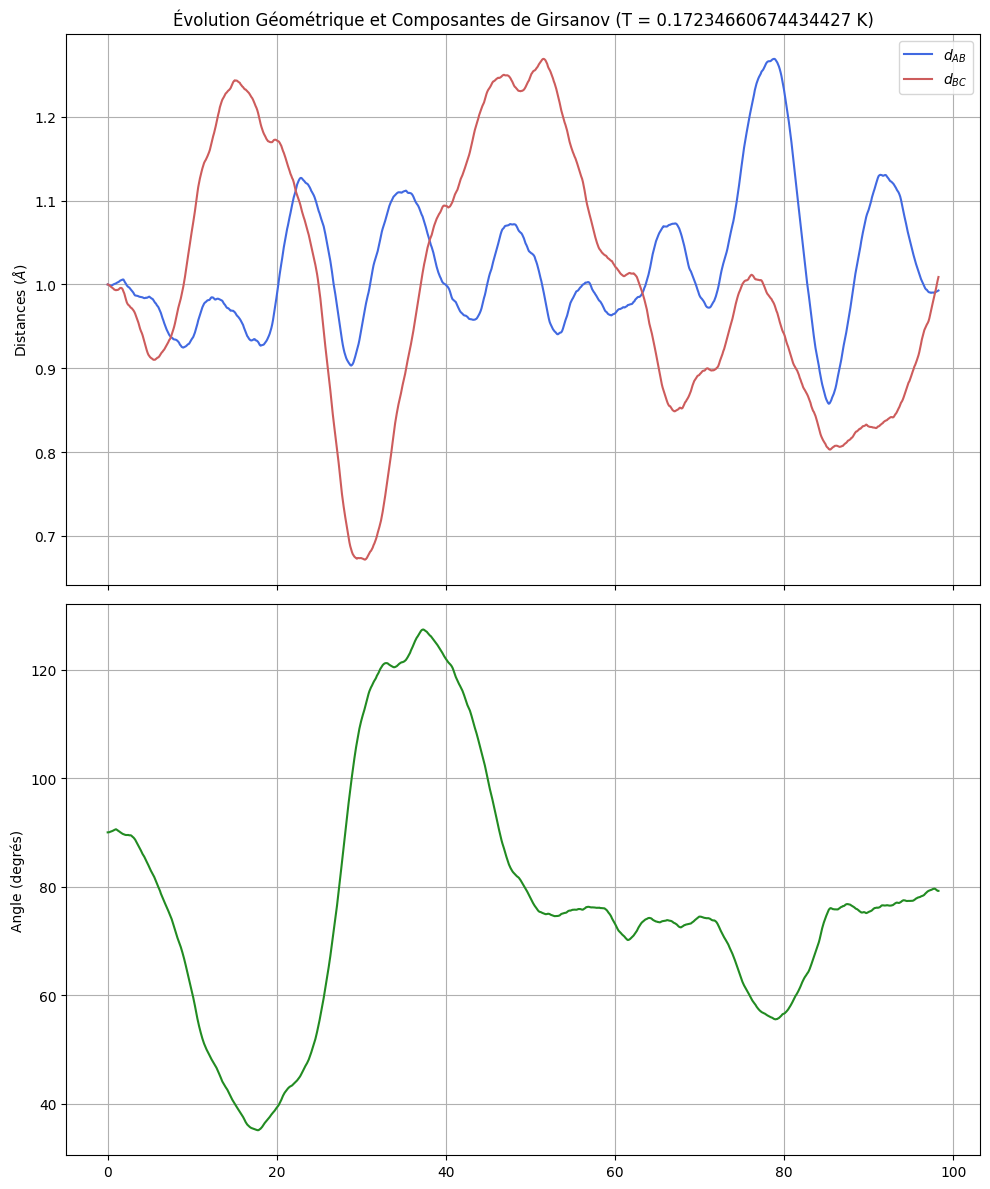

In [3]:
import matplotlib.pyplot as plt

## Visualisation de l'évolution de la coordonnée de réaction pour fixer les limites des états.
times = []
d_ab_values = []
d_bc_values = []
angles_values = []

def monitor_and_store():
    d_ab = atoms.get_distance(0, 1, mic=False)
    d_bc = atoms.get_distance(1, 2, mic=False)
    angle_abc = atoms.get_angle(0, 1, 2, mic=False)
    
    times.append(dyn.get_number_of_steps() * dyn.dt)
    d_ab_values.append(d_ab)
    d_bc_values.append(d_bc)
    angles_values.append(angle_abc)

dyn.attach(monitor_and_store, interval=1)
dyn.run(1000)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12), sharex=True)

ax1.plot(times, d_ab_values, label="$d_{AB}$", color='royalblue')
ax1.plot(times, d_bc_values, label="$d_{BC}$", color='indianred')
ax1.set_ylabel("Distances ($\AA$)")
ax1.set_title(f"Évolution Géométrique et Composantes de Girsanov (T = {dyn.temp} K)")
ax1.legend()
ax1.grid(True)

ax2.plot(times, angles_values, color='forestgreen')
ax2.set_ylabel("Angle (degrés)")
ax2.grid(True)


plt.tight_layout()


In [4]:
cv.set_r_crit("below")
cv.set_in_r_boundary(1.08)
cv.set_sigma_r_level(1.1)
cv.set_out_of_r_zone(1.3)

cv.set_p_crit("above")
cv.set_in_p_boundary(1.8)
# calc.plot_pes()
rng_ams, rng_ini, rng_dyn_ini, rng_dyn_ams = [np.random.default_rng(s) for s in [0, 0, 0, 0]]


In [5]:
import shutil
## Echantillonnage des conditions initiales
shutil.rmtree("./ini_conds_normal", ignore_errors=True)
sampler = SingleWalkerSampler(dyn,
                              cv,
                              cv_interval=1,
                              fixcm=True, rng = rng_ini)
sampler.set_run_dir("./ini_conds_normal", append_traj=False)
sampler.set_ini_cond_dir("./ini_conds_normal", clean=False)
print(f"Génération de {25} conditions initiales brutes...")
sampler.sample(25)

Génération de 25 conditions initiales brutes...


In [6]:
## Calcul de la probabilité de transition via l'AMS

n_ams = 1
n_rep = 25
probas = []
seeds_ams = rng_ams.choice(10**6, size=10)
seeds_dyn = rng_dyn_ams.choice(10**6, size=10)
for k in range(n_ams):
    rng_ams = np.random.default_rng(seeds_ams[k])
    rng_dyn_ams = np.random.default_rng(seeds_dyn[k])
    
    dyn_ams = LangevinOBABO(atoms,
                       fixcm=True,
                       timestep=1.0 * units.fs,
                       temperature_K=temperature_K,
                       friction=0.2 / units.fs,
                       logfile=None,
                       trajectory=None,
                       rng=rng_dyn_ams, compute_girsanov = True)
    ams = AMS(n_rep=n_rep,
              k_min=1,
              dyn=dyn_ams,
              xi=cv,
              fixcm=True,
              save_all=False,
              rc_threshold=1e-6,
              verbose=False,
              rng=rng_ams)
    ams.set_ini_cond_dir("ini_conds_normal/")
    ams._reuse_ini_conds()
    ams.set_ams_dir("AMS_" + str(k) + "/", clean=True)
    
    ams._initialize()
    ams.run()
    probas.append(ams.p_ams())

res = np.array([np.mean(probas), np.std(probas, ddof=1) / np.sqrt(len(probas))])
print(res)
# np.savetxt('results.txt', res)

[0.00659723        nan]


/work/moracchl/anaconda3/envs/aseams/lib/python3.14/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/work/moracchl/anaconda3/envs/aseams/lib/python3.14/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


517


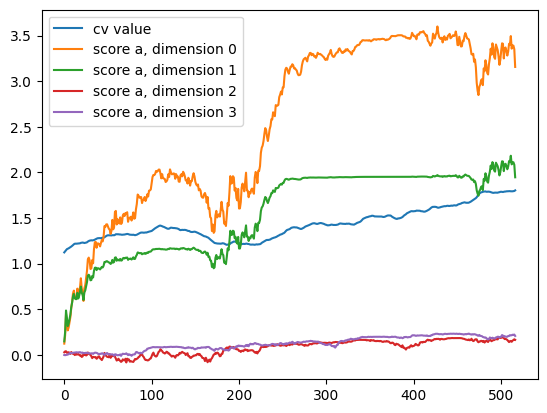

In [7]:
## Visualisation du score a de Girsanov sur une trajectoire finale.

from ase.io import read
traj = read('./AMS_0/rep_1.traj', index='1:')
def get_d_BC(atoms):
    return atoms.get_distance(0, 1, mic=False)
cv_values = [get_d_BC(atoms) for atoms in traj]
score_values = np.array([atoms.info['girsanov_a'] for atoms in traj])
import matplotlib.pyplot as plt
plt.plot(cv_values, label = 'cv value')
print(len(cv_values))
for i in range(4):
    plt.plot(score_values[:,i], label =f"score a, dimension {i}")
plt.legend()